# 
Машинное обучение, DS-поток
## Задание ML.1

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


**Правила оформления теоретических задач:**

* Решения необходимо прислать одним из следующих способов:
  * фотографией в правильной ориентации, где все четко видно, а почерк разборчив,
    * отправив ее как файл боту вместе с ноутбуком *или*
    * вставив ее в ноутбук посредством `Edit -> Insert Image` (<font color="red">фото, вставленные ссылкой, не принимаются</font>);
  * в виде $\LaTeX$ в markdown-ячейках.
* Решения не проверяются, если какое-то требование не выполнено. Особенно внимательно все проверьте в случае выбора второго пункта (вставки фото в ноутбук). <font color="red"><b>Неправильно вставленные фотографии могут не передаться при отправке.</b></font> Для проверки попробуйте переместить `ipynb` в другую папку и открыть его там.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash; 15 баллов;
* Задача 2 &mdash; 35 баллов;
* Задача 3 &mdash; 30 баллов;
* Задача 4 &mdash; 100 баллов;
* Задача 5 &mdash; будут объявлены позже.

----

In [1]:
# Bot check

# HW_ID: ds_ml1
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [27]:
import numpy as np
import pandas as pd
import scipy.stats as sps
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, root_mean_squared_error
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from time import time
from tqdm.notebook import tqdm
from typing import Tuple, List, Dict, Any, Optional

sns.set_theme(palette='Set2', font_scale=1.2)

---
### Задача 1.

Выведите итерационную формулу пересчета коэффициентов модели с помощью формулы решения через проксимальный оператор для Ridge-регрессии. Что можно сказать о влиянии параметра регуляризации?

![1](1.png)

---
### Задача 2.

Исследуем Elastic-регрессию.

**1.** Визуализируйте множество, которое ограничивает коэффициенты в Elastic-регрессии.

In [28]:
RANDOM_STATE = 42

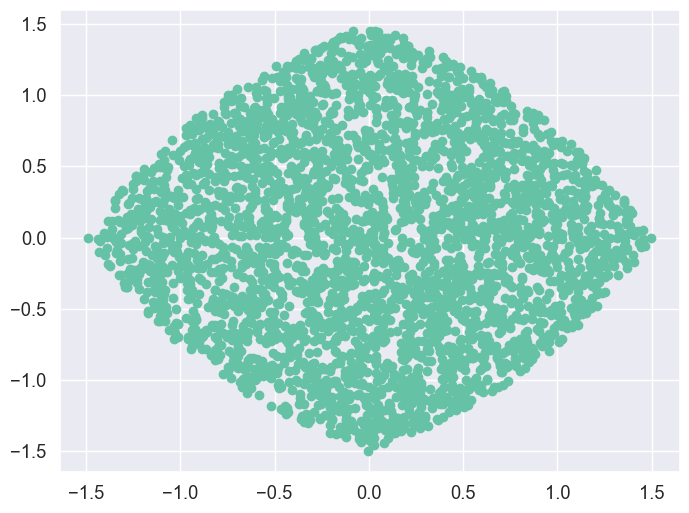

In [29]:
rng = np.random.default_rng(RANDOM_STATE)
M = 10000
dots = (2 * rng.random(size=(M, 2)) - 1) * 2
R = 1
selected_dots = []

for i in range(M):
    dot = dots[i, :]
    if np.sqrt(dot[0] ** 2 + dot[1] ** 2) + abs(dot[0]) + abs(dot[1]) <= 3:
        selected_dots.append(dot)

selected_dots = np.array(selected_dots)

plt.figure(figsize=(8, 6))
plt.scatter(selected_dots[:, 0], selected_dots[:, 1])
plt.show()

**2.** Выведите итерационную формулу пересчета коэффициентов модели с помощью формулы решения через проксимальный оператор.

Какой вы можете видеть эффект при изменении параметра регуляризации и в чем
его отличие от лассо-регрессии?

см. влож.

**3.** Выпишите формулы для градиентного и стохастического спуска.

см. влож.

---
### Задача 3.

Рассмотрим модель логистической регрессии. Признаки объекта представимы в виде $d$-мерного вектора $x \in \mathbb{R}^d$, класс имеет бернулиевское распределение $Y \sim Bern(\mu_\theta(x))$. Мы делаем следующее предположение о зависимости параметра вероятности от признаков:
$${\mu_\theta(x) = \sigma(x^T\theta)= \cfrac{1}{1 + e^{-x^T\theta}}}.$$

Зададим регуляризацию через минимизацию следующего функционала:

$$F(\theta) = -\sum_{i=1}^n \left[Y_i \log{\sigma(\theta^T x_i)} + (1 - Y_i) \log{\left(1 - \sigma(\theta^T x_i)\right)}\right] + \lambda\theta^T \theta.$$

**1.** Выведите формулы градиентного спуска (GD) и стохастического градиентного спуска (SGD).

**2.** Покажите, что $F(\theta)$ &mdash; выпуклая функция по $\theta$ и, как следствие, имеет единственный экстремум, являющийся глобальным максимумом. *Указание*. Посчитайте гессиан (матрицу вторых производных) и покажите, что она положительно определена.

**3.** Опишите, как может вести себя решение при отсутствии регуляризации, то есть при $\lambda = 0$

см. влож.

---
### Задача 4.


**Введение**

Рассмотрим обезличенные [данные](https://www.kaggle.com/datasets/juice0lover/users-vs-bots-classification) о профилях пользователей ВК. Здесь собрана информация почти о 6 тыс. аккаунтах. Часть из них принадлежит реальным людям, а часть &mdash; боты. В этой задаче вы увидите, как регуляризация влияет на интерпретацию коэффициентов модели логистической регрессии.

**Описание датасета**

Данные содержат 60 столбцов. Столбец `target` &mdash; метка целевого класса (бот/пользователь). Признаки можно условно разбить на несколько групп:

1. Числовые признаки:
    -   Метрики активности (среднее кол-во постов за неделю)
    -   Количество друзей/подписчиков
2. Категориальные признаки:
    -   Атрибуты профиля (установлен ли аватар, указан ли номер телефона)
    -   Город
    -   Настройки приватности (закрытый/открытый профиль)
    -   Различные бинарные флаги (можно ли писать в личные сообщения)

**1.** **Загрузка и подготовка данных**

Загрузите датасет, выведите его размер и описание числовых фичей при помощи метода `describe`. Отличается ли масштаб у числовых признаков?

In [30]:
df = pd.read_csv('bots_vs_users.csv')
print(df.shape)
df.describe()

(5874, 60)


,target,posts_count,avg_likes,links_ratio,hashtags_ratio,avg_keywords,avg_text_length,attachments_ratio,avg_comments,reposts_ratio,ads_ratio,avg_views,posting_frequency_days,phone_numbers_ratio,avg_text_uniqueness
count,5874.000000,1391.000000,1391.000000,1391.000000,1391.000000,1391.000000,1391.000000,1391.000000,1391.000000,1391.000000,1391.000000,1391.000000,1391.000000,1391.000000,1391.000000
mean,0.500000,18.629044,19.552487,0.156463,0.143918,7.730661,544.752035,0.895945,0.610812,0.433638,0.002667,623.834788,66.330065,0.000568,0.668009
std,0.500043,4.231994,41.954881,0.202730,0.187085,11.278711,746.728130,0.170084,2.461709,0.397830,0.033136,1617.635460,154.970296,0.009545,0.229815
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,20.000000,0.400000,0.000000,0.000000,1.100000,86.600000,0.850000,0.000000,0.050000,0.000000,9.125000,1.980000,0.000000,0.580000
50%,0.500000,20.000000,7.600000,0.100000,0.050000,3.400000,267.800000,0.950000,0.000000,0.300000,0.000000,268.950000,30.950000,0.000000,0.710000
75%,1.000000,20.000000,26.075000,0.200000,0.200000,7.850000,616.850000,1.000000,0.200000,0.900000,0.000000,746.050000,89.480000,0.000000,0.830000
max,1.000000,20.000000,894.900000,1.000000,1.000000,61.600000,5841.250000,1.000000,64.050000,1.000000,0.950000,41415.700000,2866.590000,0.300000,1.000000


**Ответ:** Да, отличается, скажем, avg_likes и avg_views: std отличаются более чем в сто раз, максимумы 900 и 41000 соотвественно. Нужно не забыть отнормировать. Но пока непонятно, все ли признаки имеют одинаковые веса в определении таргета

Подсчитайте количество уникальных значений в столбце `city` и выведите 5 наиболее частых городов.

In [31]:
print('Количество уникальных значений в столбце city:', df.loc[:, 'city'].nunique())
df.loc[:, 'city'].value_counts().head(5)

Количество уникальных значений в столбце city: 362


city
Unknown             2780
Saint Petersburg    1549
Kostomuksha          405
Moscow               335
Petrozavodsk         103
Name: count, dtype: int64

**Вывод:** У многих пользователей город не указан. Взяв только тех, что указали город, большинство будет из Санкт-Петербурга

Само название города, который указан в профиле, нам не особо важно. **Замените** этот признак на простой бинарный флаг: указан/отсутствует.

In [32]:
df.loc[:, 'city'] = (df.loc[:, 'city'] != 'Unknown')

In [33]:
print('Количество уникальных значений в столбце city:', df['city'].nunique())
df.loc[:, 'city'].value_counts()

Количество уникальных значений в столбце city: 2


city
True     3094
False    2780
Name: count, dtype: int64

Выделите целевую переменную и матрицу признаков, убрав из неё лишние столбцы:

In [34]:
y = df.loc[:, 'target']
X = df.drop(['target'], axis=1)

Посчитайте количество нулей и единиц таргете. Лучше всего представить ответ в виде графика с двумя столбцами, высота которых соответствует количеству объектов класса (см. например, [`sns.countplot`](https://seaborn.pydata.org/generated/seaborn.countplot.html)). Есть ли дисбаланс между классами?

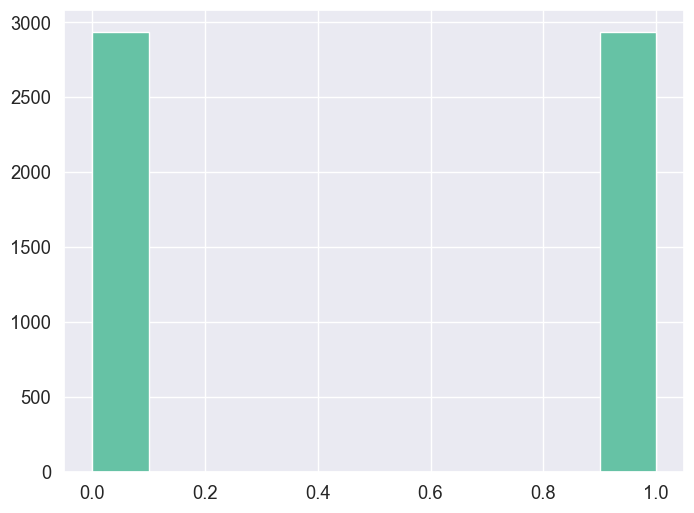

In [35]:
plt.figure(figsize=(8, 6))
plt.hist(y)
plt.show()

**Ответ:** Классы сбалансированны

Разделите данные на трейн и тест. Аналогичным образом выведите распределение таргета по классам для обеих выборок. Соотношение классов в обучающей и тестовой частях должно быть одинаковым.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE, train_size=0.5)

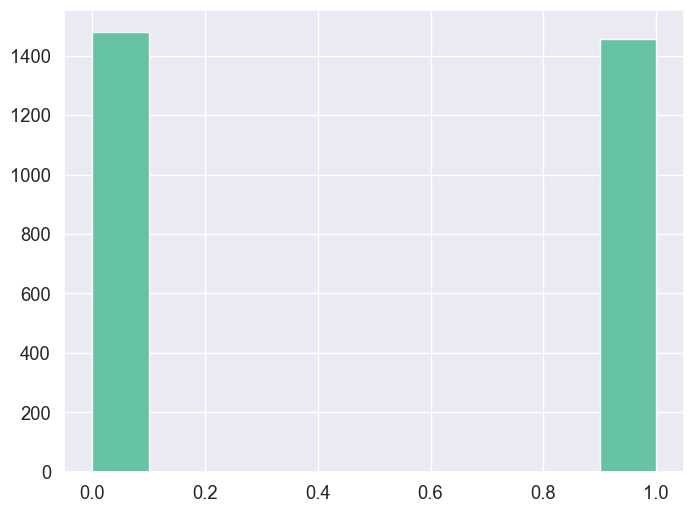

In [37]:
plt.figure(figsize=(8, 6))
plt.hist(y_train)
plt.show()

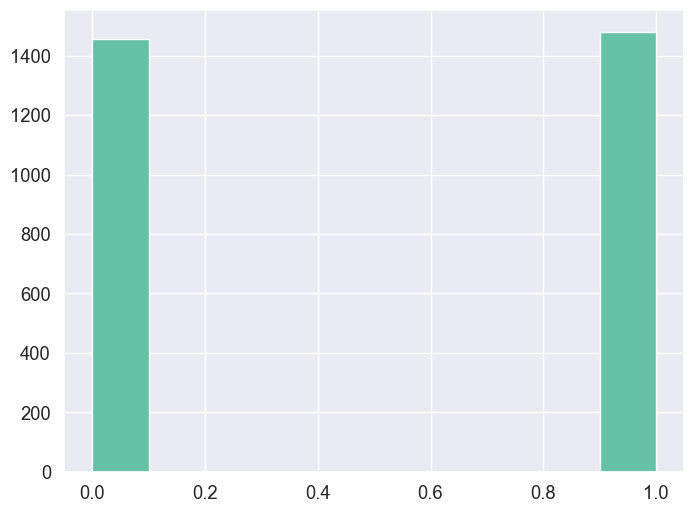

In [38]:
plt.figure(figsize=(8, 6))
plt.hist(y_test)
plt.show()

**Ответ:** Таргет распеределён равномерно

Согласно описанию на странице датасета, в данных присутствуют пропуски. Причём в числовых признаках они отмечены значением `NaN`, а в категориальных &mdash; строкой `"Unknown"`. Используя [`SimpleImputer`](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html), заполните **числовые пропуски** средними значениями. Для каждого числового признака с пропусками создайте дополнительный признак-флаг, указывающий на наличие или отсутствие пропуска. Преобразуйте **только обучающую** выборку и убедитесь, что `NaN`-ов в ней действительно нет.

In [39]:
X_train.isna().any().any()

True

In [40]:
imp_mean = SimpleImputer(strategy='mean')
flag1 = X_train.isna().any()
X_train.loc[:, flag1] = imp_mean.fit_transform(X_train.loc[:, flag1])

In [41]:
X_train.isna().any().any()

False

К категориальным признакам примените преобразование [OneHotEncoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html). При этом значения `"Unknown"` следует также распознавать как отдельную категорию.

In [42]:
(X_train == 'Unknown').any().any()

True

In [43]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
flag2 = (X_train == 'Unknown').any()
cat_features = X_train.columns[flag2]
X_cat = ohe.fit_transform(X_train.loc[:, flag2].astype(str))
X_cat = pd.DataFrame(X_cat, columns=ohe.get_feature_names_out(), index=X_train.index)
X_train = pd.concat([X_train.drop(cat_features, axis=1), X_cat], axis=1)

In [44]:
(X_train == 'Unknown').any().any()

False

Стандартизируйте **обучающую выборку** при помощи `MinMaxScaler`, задав интервал $[-1, 1]$. `StandardScaler` здесь лучше не использовать, поскольку заполненные пропуски станут принимать разные значения у разных фичей. `MinMaxScaler` гарантирует нам, что значение $-1$ всегда будет соответствовать пропуску, т. к. сами признаки неотрицательны.

In [45]:
scaler = MinMaxScaler()
columns = X_train.columns
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=columns, index=X_train.index)

Хорошо ли обусловлена преобразованная матрица $X$? О чём это говорит?

In [46]:
np.linalg.cond(X_train_scaled)

9.31563996418203e+19

**Ответ:** Число обусловенности огромное, это связано с количеством признаков. Значит, высокая степень мультиколлениарности, зависимости между признаками близки к линейным

Для наглядности, выведите матрицу корреляций. Что означают элементы матрицы? А в нашем случае?

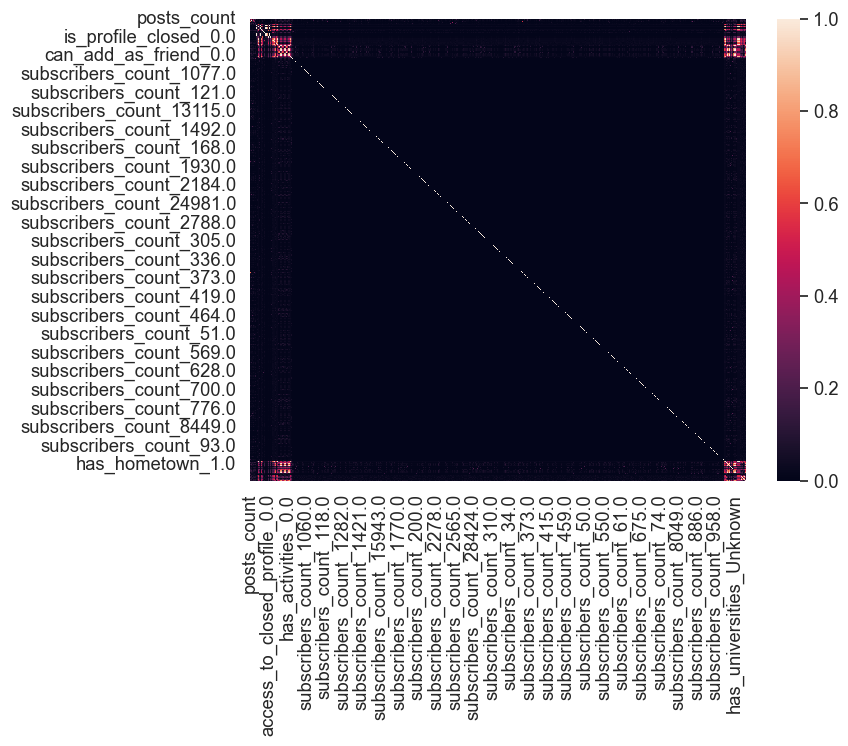

In [47]:
plt.figure(figsize=(8, 6))
sns.heatmap(X_train_scaled.corr().abs())
plt.show()

**Ответ:** Видим несколько светлых пятен. Многие индикаторы отражают близкие по своей сути вещи.

Мы сделали 3 преобразования над данными. Делать это вручную не вполне удобно и правильно. Гораздо лучше использовать пайплайн. Для этого зададим порядок выполнения преобразований так, как этого требует объект типа [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html):

In [48]:
preproc_steps = [
    ('num_imputer', SimpleImputer(strategy='mean')),
    ('one_hot', OneHotEncoder()),
    ('scaler', MinMaxScaler())
]

Теперь для создания пайплайна достаточно добавить саму модель как четвёртый шаг:


```
model = Pipeline(
    steps=preproc_steps + [
        ('estimator', <Инизиализированная модель>)
    ]
)
```
Такой подход является более надёжным и удобным.

**2.** **Модельки, модельки, модельки...**

**2.1** **Логистическая регрессия без регуляризации**

Обучите классическую лог. регрессию без регуляризации и выведите точность ответа на трейне и тесте.

<details>
  <summary>  Подсказка ✍️</summary>
  
Чему равен аргумент `penalty` по умолчанию?
 </details><br/>

In [49]:
model = LogisticRegression(penalty=None, max_iter=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_train_scaled)
print(accuracy_score(y_train, y_pred))

0.9853592100783112


In [50]:
flag1 = X_test.isna().any()
X_test.loc[:, flag1] = imp_mean.transform(X_test.loc[:, flag1])

In [51]:
flag2 = (X_test == 'Unknown').any()
cat_features = X_test.columns[flag2]
X_cat = ohe.transform(X_test.loc[:, flag2].astype(str))
X_cat = pd.DataFrame(X_cat, columns=ohe.get_feature_names_out(), index=X_test.index)
X_test = pd.concat([X_test.drop(cat_features, axis=1), X_cat], axis=1)

In [52]:
columns = X_test.columns
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=columns, index=X_train.index)

In [53]:
y_pred = model.predict(X_test_scaled)
print(accuracy_score(y_test, y_pred))

0.95097037793667


**Вывод:** Модель предсказывает чуть хуже на тестовых данных, но тем не менее очень точно. К тестовым данным применил аналогичную предобработку, что и к обучающим, хотя выше просят применять только к тестовым. Но тогда непонятно, как модель будет предсказывать, если там NaN и Unknown, OHE

**2.2** **Логистическая регрессия с регуляризацией**

За что отвечает гиперпараметр `C` у класса `LogisticRegression`?

**Ответ:** C отвечает за силу регуляризации. Чем он меньше, тем регуляризация больше

Вам необходимо исследовать зависимость от `C` следующих величин:
1. Accuracy на трейне
2. Accuracy на тесте
3. Коэффициенты модели

Чтобы не приходилось постоянно обучать модели при одних и тех же сетках `C`, предлагается написать функцию, которая будет принимать на вход вид штрафа `penalty`, границы диапазона `C`, и саму выборку. На каждой итерации вычисляйте все величины и сохраняйте в виде списков. Для мониторинга времени работы используйте функцию `tqdm`.

In [54]:
def train_alpha_grid(
    log_C_bounds: Tuple[float, float],
    resolution: int,
    data: Dict[str, Any],
    preproc_steps: List[Tuple[str, Any]] = None,
    penalty: str = 'none',
    solver: str = 'saga',
    max_iter: int = 100,
) -> Tuple[List[np.ndarray], List[float], List[float]]:
    """Обучает модель LogisticRegression для разных значений параметра регуляризации C,
    сохраняет коэффициенты, вычисляет accuracy на обучающей и тестовой выборках.

    Args:
        log_C_bounds (Tuple[float, float]): кортеж с минимальным и максимальным значением log10(C) для сетки.
        resolution (int): число точек на сетке C.
        data (dict): словарь с обучающей и тестовой выборками (например, {'X_train': ..., 'y_train': ..., 'X_test': ..., 'y_test': ...}).
        preproc_steps (List[Tuple[str, Any]]): список шагов пайплайна.
        penalty (str): тип регуляризации ('l1', 'l2', 'elasticnet', 'none').
        solver (str): метод оптимизации параметров модели (см. аргумент `solver` у класса LogisticRegression).
        max_iter (int): обучение останавливается, если требуемая точность не достигнута за max_iter итераций.

    Returns:
        coefs_list (List[np.ndarray]): список массивов коэффициентов для каждого значения C.
        acc_train_list (List[float]): список accuracy на обучающей выборке для каждого значения C.
        acc_test_list (List[float]): список accuracy на тестовой выборке для каждого значения C.
    """

    coefs_list = []
    acc_train_list = []
    acc_test_list = []

    X_train = data['X_train']
    X_test = data['X_test']
    y_train = data['y_train']
    y_test = data['y_test']

    if preproc_steps:
        for step_name, preproc_step in preproc_steps:
            X_train = preproc_step.fit_transform(X_train)
            X_test = preproc_step.transform(X_test)
            

    C_grid = np.logspace(log_C_bounds[0], log_C_bounds[1], resolution)
    for C in tqdm(C_grid):
        
        model = LogisticRegression(penalty=penalty, solver=solver, C=C, max_iter=max_iter, l1_ratio=0.5)
        model.fit(X_train, y_train)

        coefs_list.append(np.array(model.coef_))
        
        y_train_pred = model.predict(X_train)
        acc_train_list.append(accuracy_score(y_train, y_train_pred))
        
        y_test_pred = model.predict(X_test)
        acc_test_list.append(accuracy_score(y_test, y_test_pred))

    return coefs_list, acc_train_list, acc_test_list

Проведите эксперимент для 3-х разных моделей логистической регрессии с различными типами регуляризации:
1.  $L_1$-регуляризация
2.  $L_2$-регуляризация
3.  Комбинированная регуляризация с параметром `l1_ratio=0.5`.

>*Рекомендации*
>*   Подберите диапазоны значений для гиперпараметра `C`. Не берите слишком узкие, чтобы видеть на графике всю картину. Для слишком широких границ придётся брать больше точек.
>*   Вам не нужна очень частая сетка гиперпараметра `C`. При отладке кода можно вообще использовать сетку из 2-3 значений.
>*   Вы можете столкнуться с различными ошибками и `warning`-ами (например, неверный `solver`, отсутствие сходимости,  и т.д.). Постарайтесь настроить гиперпараметры модели таким образом, чтобы ошибки исчезли, а количество предупреждений было минимальным.

Выберите 8-15 признаков на своё усмотрение либо случайным образом. Нарисуйте треки соответствующих коэффициентов моделей в зависимости от `C`. Свободный коэффициент тоже стоит добавить на графики. Легенду можно сделать общую, если все графики помещаются на экране. Отразите в ней наименования признаков для соответствующих коэффициентов. Сделать красиво могут помочь заметки [отсюда](https://stackoverflow.com/questions/4700614/how-to-put-the-legend-outside-the-plot).

In [55]:
size = 15
cols = rng.integers(low = 0, high=60, size=size)
X_train_scaled_new = X_train_scaled.iloc[:, cols]
X_test_scaled_new = X_test_scaled.iloc[:, cols]

In [56]:
bounds = (2, 4)
data = {'X_train': X_train_scaled_new, 'X_test': X_test_scaled_new, 'y_train': y_train, 'y_test': y_test}
resolution = 10
penalty = 'elasticnet'
max_iter = 100

coefs_list_elasticnet, acc_train_list_elasticnet, acc_test_list_elasticnet = train_alpha_grid(log_C_bounds=(np.log10(bounds[0]), np.log10(bounds[1])),
                                                             resolution=resolution, data=data, 
                                                             penalty=penalty, max_iter=max_iter)

C_grid_elasticnet = np.logspace(np.log10(bounds[0]), np.log10(bounds[1]), resolution)

  0%|          | 0/10 [00:00<?, ?it/s]

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was re

In [57]:
coefs2d = np.vstack(coefs_list_elasticnet)

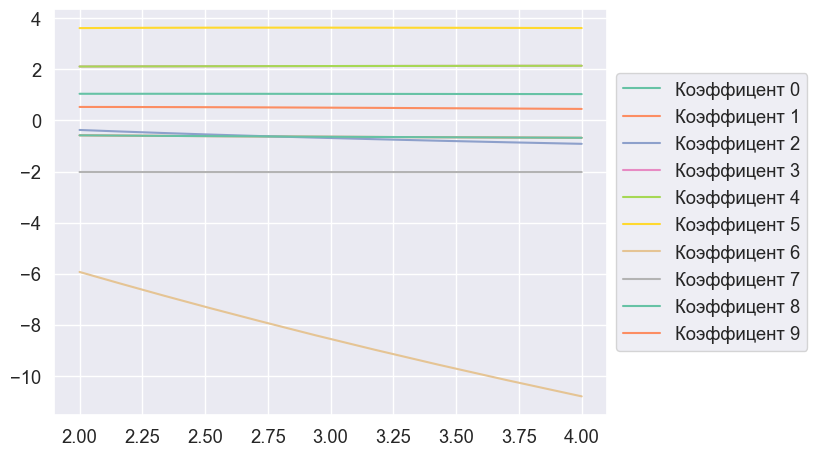

In [58]:
fig = plt.figure()
ax = plt.subplot(111)

for i in range(resolution):
    ax.plot(C_grid_elasticnet, coefs2d[:, i], label=f'Коэффицент {i}')

ax = plt.subplot(111)
plt.legend()
plt.tight_layout()
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

**Вывод:** Коэффиценты зависият от параметра регуляризации

Нарисуйте зависимости точности предсказания от `C` на обучающей и тестовой выборках. Скомпонуйте всё на 2-3 графиках. Горизонтальными линиями отметьте точность модели без регуляризации на тесте.

In [59]:
bounds = (2, 4)
data = {'X_train': X_train_scaled, 'X_test': X_test_scaled, 'y_train': y_train, 'y_test': y_test}
resolution = 10
penalty = 'elasticnet'
max_iter = 100

coefs_list_elasticnet, acc_train_list_elasticnet, acc_test_list_elasticnet = train_alpha_grid(log_C_bounds=(np.log10(bounds[0]), np.log10(bounds[1])),
                                                             resolution=resolution, data=data, 
                                                             penalty=penalty, max_iter=max_iter)

C_grid_elasticnet = np.logspace(np.log10(bounds[0]), np.log10(bounds[1]), resolution)

  0%|          | 0/10 [00:00<?, ?it/s]

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was re

In [60]:
bounds = (0.0001, 2.5)
data = {'X_train': X_train_scaled, 'X_test': X_test_scaled, 'y_train': y_train, 'y_test': y_test}
resolution = 10
penalty = 'l1'
max_iter = 100

coefs_list_l1, acc_train_list_l1, acc_test_list_l1 = train_alpha_grid(log_C_bounds=(np.log10(bounds[0]), np.log10(bounds[1])),
                                                             resolution=resolution, data=data, 
                                                             penalty=penalty, max_iter=max_iter)

C_grid_l1 = np.logspace(np.log10(bounds[0]), np.log10(bounds[1]), resolution)

  0%|          | 0/10 [00:00<?, ?it/s]

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\skl

In [61]:
bounds = (2, 10)
data = {'X_train': X_train_scaled, 'X_test': X_test_scaled, 'y_train': y_train, 'y_test': y_test}
resolution = 10
penalty = 'l2'
max_iter = 100

coefs_list_l2, acc_train_list_l2, acc_test_list_l2 = train_alpha_grid(log_C_bounds=(np.log10(bounds[0]), np.log10(bounds[1])),
                                                             resolution=resolution, data=data, 
                                                             penalty=penalty, max_iter=max_iter)

C_grid_l2 = np.logspace(np.log10(bounds[0]), np.log10(bounds[1]), resolution)

  0%|          | 0/10 [00:00<?, ?it/s]

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:34

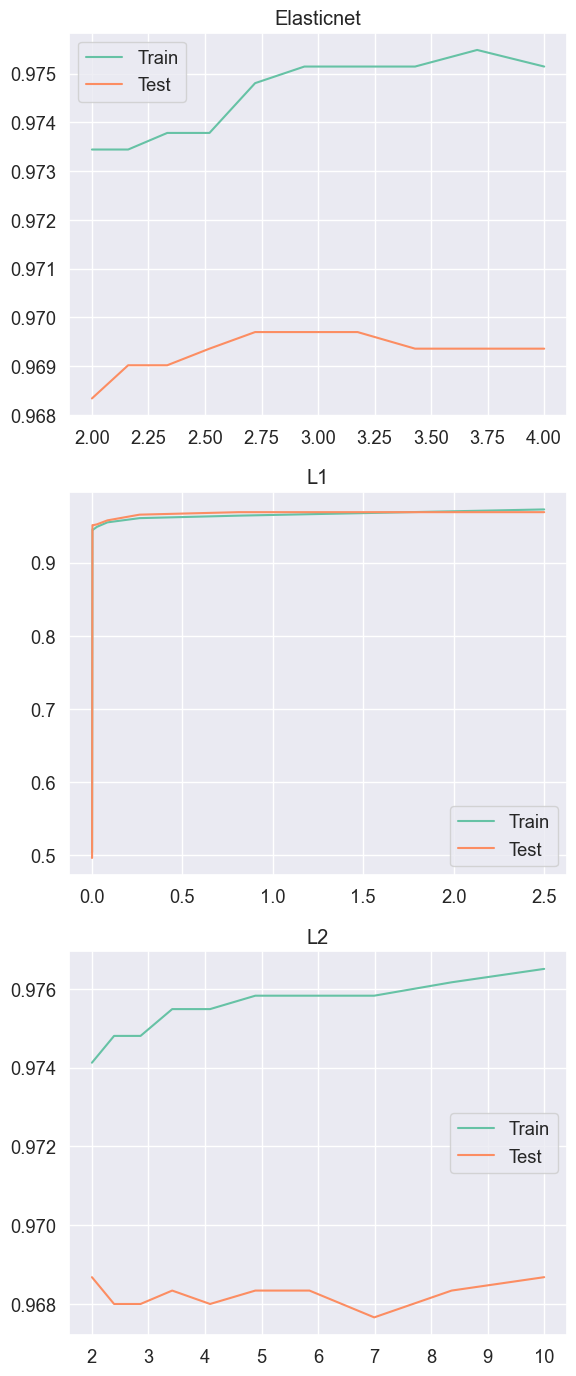

In [62]:
fig, axes = plt.subplots(figsize=(6, 14), nrows=3)
axes[0].plot(C_grid_elasticnet, acc_train_list_elasticnet, label='Train')
axes[0].plot(C_grid_elasticnet, acc_test_list_elasticnet, label='Test')
axes[0].set_title('Elasticnet')
axes[0].legend()

axes[1].plot(C_grid_l1, acc_train_list_l1, label='Train')
axes[1].plot(C_grid_l1, acc_test_list_l1, label='Test')
axes[1].set_title('L1')
axes[1].legend()

axes[2].plot(C_grid_l2, acc_train_list_l2, label='Train')
axes[2].plot(C_grid_l2, acc_test_list_l2, label='Test')
axes[2].set_title('L2')
axes[2].legend()

plt.tight_layout()
plt.show()

Сделайте вывод. Есть ли польза от регуляризации с точки зрения метрики?

**Вывод:** Как видим, от ругеляризации и от её степени действительно меняется метрика, иногда в лучшую, иногда в худшую, сторону. Однако всегда можно подобрать оптимальные параметры при начличии необходимых вычислительных мощностей

**3.** **Число обусловленности**

Исследуйте зависимость числа обусловленности от параметра `C` для $L_2$-регуляризации. Постройте соответствующий график.

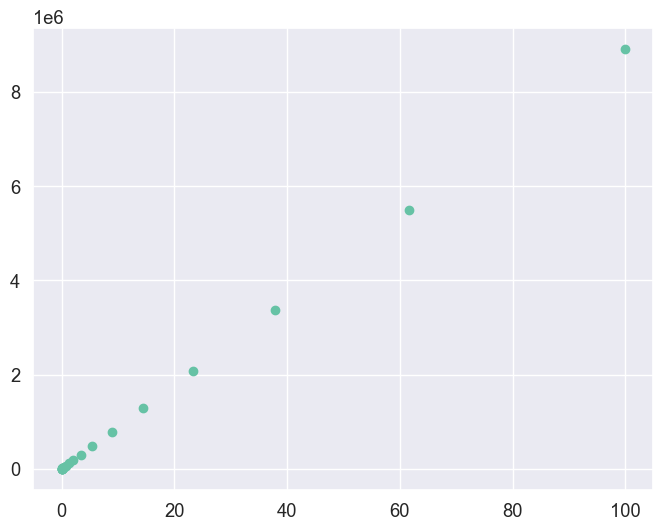

In [63]:
conds = []
C_grid = np.logspace(-2, 2, 20)
for C in C_grid:
    conds.append(np.linalg.cond(X_train_scaled.T @ X_train_scaled + 1 / C * np.eye(X_train_scaled.shape[1])))

plt.figure(figsize=(8, 6))
plt.scatter(C_grid, conds)
plt.show()

Сделайте вывод. О чём свидетельствует полученная зависимость?

**Вывод:** Чем больше C, тем меньше число обусловелнности. Причём отличие может быть в миллионы раз. Завсисимость же похожа на линейную

**4.** **Разброс коэффициентов**

Рассмотрите **2 модели:** логистическая регрессия с регуляризацией по-умолчанию и с `penalty=None`. Каждую модель обучите 500 раз при различных разбиениях на обучающую и тестовую выборки. Сохраните коэффициенты для выбранных ранее признаков. Подсчитайте усреднённую метрику качества и визуализируйте распределение каждого коэффициента. Не забудьте про пайплайн.

> Визуализацию предлагается сделать виде сетки графиков. На каждом изобразите **ядерные оценки плотности** для соответствующего коэффициента обеих моделей.
>
> Также напоминаем про удобство использования [логарифмической шкалы](https://matplotlib.org/stable/api/scale_api.html#builtin-scales).

In [64]:
y = df.loc[:, 'target']
X = df.drop(['target'], axis=1)

In [65]:
X.shape

(5874, 59)

In [66]:
size = 15

cols = rng.choice(X.columns, size=size, replace=False)
X = X[cols]

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

X.loc[:, cat_cols] = X.loc[:, cat_cols].astype(str)

In [67]:
from sklearn.compose import ColumnTransformer

In [68]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())
])

categories = [sorted(X[col].astype(str).unique()) for col in cat_cols]

cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', categories=categories))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
], remainder='drop')

In [69]:
clf1 = Pipeline([
    ('preproc', preprocessor),
    ('model', LogisticRegression(max_iter=500))
])

clf2 = Pipeline([
    ('preproc', preprocessor),
    ('model', LogisticRegression(penalty=None, max_iter=500))
])

In [70]:
n = 500
metrics1 = []
metrics2 = []
coefs1 = []
coefs2 = []

for i in tqdm(range(n)):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=i, train_size=0.5)
    
    clf1.fit(X_train, y_train)
    clf2.fit(X_train, y_train)

    y_pred1 = clf1.predict(X_test)
    y_pred2 = clf2.predict(X_test)

    metrics1.append(accuracy_score(y_test, y_pred1))
    metrics2.append(accuracy_score(y_test, y_pred2))

    coefs1.append(clf1.named_steps['model'].coef_.copy())
    coefs2.append(clf2.named_steps['model'].coef_.copy())

  0%|          | 0/500 [00:00<?, ?it/s]

In [71]:
coefs1 = np.vstack(coefs1)
coefs2 = np.vstack(coefs2)

In [73]:
print(f'Среднее значение модели с регуляризацией по-умолчанию: {np.mean(metrics1)}')
print(f'Среднее значение модели без регуляризации: {np.mean(metrics2)}')

Среднее значение модели с регуляризацией по-умолчанию: 0.9399332652366361
Среднее значение модели без регуляризации: 0.9440640108954717


In [74]:
# m = coefs1.shape[1]

# fig, axs = plt.subplots(figsize=(12, m * 1.6), nrows=m, ncols=2)

# axs[0, 0].set_title('Модель с регуляризацией по-умолчанию')
# axs[0, 1].set_title('Модель без регуляризации')

# for i in range(m):
#     sns.histplot(coefs1[:, i], label=f'Коэффициент: {i}', ax=axs[i, 0], kde=True)
#     axs[i, 0].axvline(coefs1[:, i].mean())
#     axs[i, 0].legend()

#     sns.histplot(coefs2[:, i], label=f'Коэффициент: {i}', ax=axs[i, 1], kde=True)
#     axs[i, 1].axvline(coefs2[:, i].mean())
#     axs[i, 1].legend()

# plt.subplots_adjust(top=0.94, hspace=0.6, wspace=0.25)
# plt.show

# # Далее версия gpt для красоты 

In [76]:
# настройки внешнего вида
sns.set(style="whitegrid", context="talk")
colors = sns.color_palette("Set2", 2)

m = coefs1.shape[1]
fig_w = 12
fig_h = max(4, m * 1.6)   # автоматически масштабируем высоту под число коэффициентов
fig, axs = plt.subplots(nrows=m, ncols=2, figsize=(fig_w, fig_h), constrained_layout=False)

fig.suptitle("Сравнение распределений коэффициентов\n(с регуляризацией — слева | без регуляризации — справа)", fontsize=18, y=0.96)

for i in range(m):
    ax_left = axs[i, 0]
    ax_right = axs[i, 1]
    a = np.asarray(coefs1[:, i])
    b = np.asarray(coefs2[:, i])

    xmin = min(a.min(), b.min())
    xmax = max(a.max(), b.max())
    if xmin == xmax:
        xmin -= 0.5
        xmax += 0.5
    pad = (xmax - xmin) * 0.06
    xlims = (xmin - pad, xmax + pad)

    # Левый: с регуляризацией
    sns.histplot(a, kde=True, stat="density", ax=ax_left,
                 color=colors[0], alpha=0.55, edgecolor=None, linewidth=0)
    ax_left.axvline(a.mean(), color=colors[0], linestyle="--", linewidth=1.5, label=f"μ={a.mean():.3f}")
    ax_left.set_xlim(xlims)
    ax_left.set_ylabel("Плотность" if i == m-1 else "")  # подпись y только внизу (чтобы не было захламления)
    ax_left.set_title(f"Коэффициент {i}", fontsize=11)
    ax_left.text(0.98, 0.78, f"μ={a.mean():.3f}\nσ={a.std(ddof=1):.3f}",
                 transform=ax_left.transAxes, ha="right", va="top", fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none"))

    # Правый: без регуляризации
    sns.histplot(b, kde=True, stat="density", ax=ax_right,
                 color=colors[1], alpha=0.55, edgecolor=None, linewidth=0)
    ax_right.axvline(b.mean(), color=colors[1], linestyle="--", linewidth=1.5, label=f"μ={b.mean():.3f}")
    ax_right.set_xlim(xlims)
    ax_right.set_ylabel("Плотность" if i == m-1 else "")
    ax_right.set_title(f"Коэффициент {i}", fontsize=11)
    ax_right.text(0.98, 0.78, f"μ={b.mean():.3f}\nσ={b.std(ddof=1):.3f}",
                  transform=ax_right.transAxes, ha="right", va="top", fontsize=9,
                  bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none"))

# Общие подписи и оформление
for ax in axs.flatten():
    ax.tick_params(axis="both", which="major", labelsize=9)
    ax.grid(alpha=0.15)

plt.subplots_adjust(top=0.94, hspace=0.6, wspace=0.25)
plt.xlabel("Значение коэффициента", labelpad=8)  # общий xlabel (визуально относится ко всем, особенно книзу)
plt.savefig("coef_distributions_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x00000154667E4720> (for post_execute), with arguments args (),kwargs {}:


ValueError: Image size of 1200x260800 pixels is too large. It must be less than 2^16 in each direction.

ValueError: Image size of 1200x260800 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 1200x260800 with 3260 Axes>

Какой модели вы больше доверитесь при интерпретации коэффициентов? Почему разработчики sklearn по-умолчанию добавили в логистическую регрессию небольшую $L_2$-регуляризацию? В чём заключается её польза? Порассуждайте над этими вопросами и попробуйте написать интерпретацию выведенных коэффициентов.

**Вывод** Видим, что коффициенты у модели с регуляризацией имеет дисперсию всегда меньше, чем у модели без регуляризации, иногда на несколько порядков. Также во втором случае наблюдаем частое смещение среднего от наиболее встречаемого и медианы. Это связано с наличием сильных выбросов без регуляризации. И хотя модель без регуляризации в нашем конкретном случае имеет лучшую среднюю метрику (в 4 порядке), стоит довериться модели с регуляризации из-за её стабильности. Параметры регуляризации можно подобрать так, что точность будет выше (см. пред. задачи)

---
### Задача 5.

Вы работаете аналитиком в крупной компании, предоставляющей онлайн-сервис по подписке (например, стриминговый сервис видео или SaaS-платформа). Каждый месяц часть клиентов прекращает пользоваться сервисом — это называется отток (churn).

Ваша задача — построить модель, которая прогнозирует метку того, что клиент уйдёт в ближайший месяц. Такой прогноз позволит маркетинговой команде вовремя предпринимать действия для удержания клиентов, например, отправлять персональные предложения или скидки.

В соревновании вам предоставлены:
* `train.csv` — данные о клиентах с историей использования сервиса и меткой `churn` (1 — ушёл, 0 — остался).
* `test.csv` — данные новых клиентов без метки `churn`.
* `sample_submission.csv` — шаблон для ваших предсказаний.


**Основная метрика**: Accuracy на тестовой выборке.

Ваша задача — помочь компании снизить отток клиентов, создавая модели, которые умеют отделять реальных «рисковых» клиентов от стабильных.

**Некоторые советы:**
* Подумайте, какие гиперпараметры регуляризации можно менять.
* Фиксируйте `random_state` для воспроизводимости результатов.

Описание данных:
| Признак               | Тип           | Описание                            |
| --------------------- | ------------- | ----------------------------------- |
| `id`                  | целочисленный | id клиента                          |
| `avg_watch_time`      | вещественный  | среднее использование (часы/неделя) |
| `is_premium`          | бинарный      | премиум-тариф (0/1)                 |
| `last_payment_delay`  | вещественный  | задержка платежа (дни)              |
| `discount_used`       | бинарный      | использовал скидку (0/1)            |
| `fee`                 | вещественный  | ежемесячная плата                   |
| `watch_time_service`  | вещественный  | сервисная информация о среднем использовании (часы/неделя) |
| `metric_*`  | вещественный  | различные метрики о использовании сервиса |
| `churn`               | целевая       | ушёл (1) / остался (0)              |


Ссылка: https://www.kaggle.com/competitions/1-ds-2025

Инвайт: https://www.kaggle.com/t/30e6e183fe1f447696bc746726ae15e8

**Решение (baseline)**

Baseline строится на стандартизации входных признаков и обучении модели логистической регрессии с использованием регуляризации.

**Возможные направления улучшения модели (продвинутый уровень)**

- Подбор гиперпараметров.
- Посмотреть "важность признаков" через `model.coef_`.
- Попробовать feature engineering: погенерировать признаки с произведением, нелинейностью.
- Попробовать построить более сложные модели.

In [77]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [78]:
print(df_train.isna().any().any())
print(df_test.isna().any().any())

False
False


In [79]:
y = df_train['churn']
X = df_train.drop(['churn'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=RANDOM_STATE)

In [80]:
from sklearn.preprocessing import StandardScaler

In [81]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

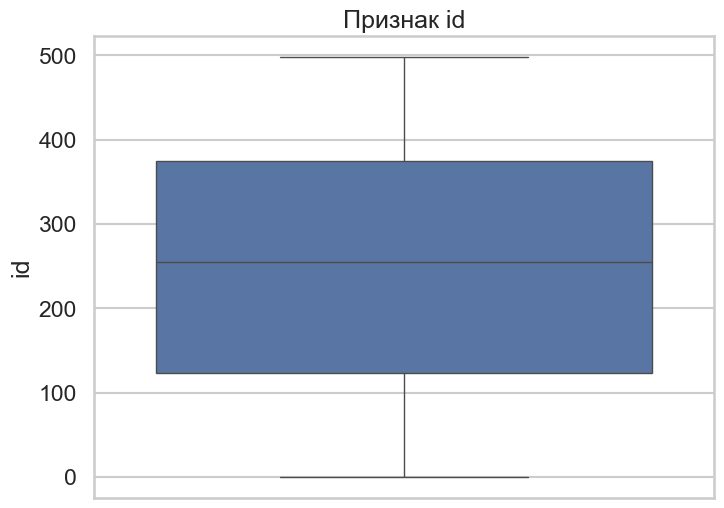

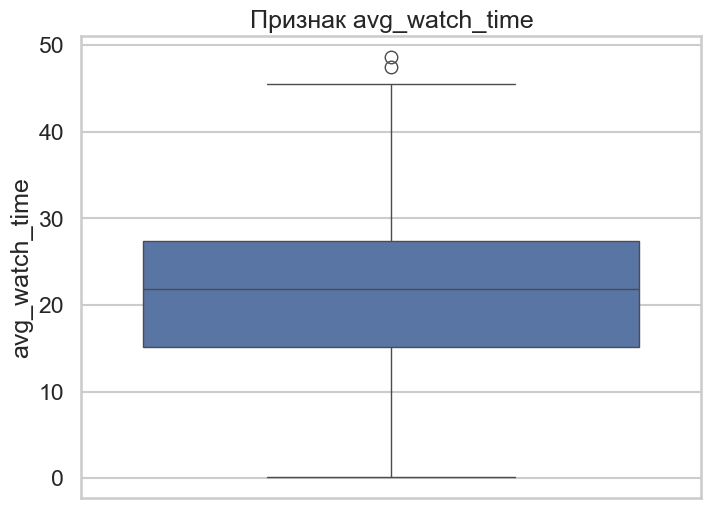

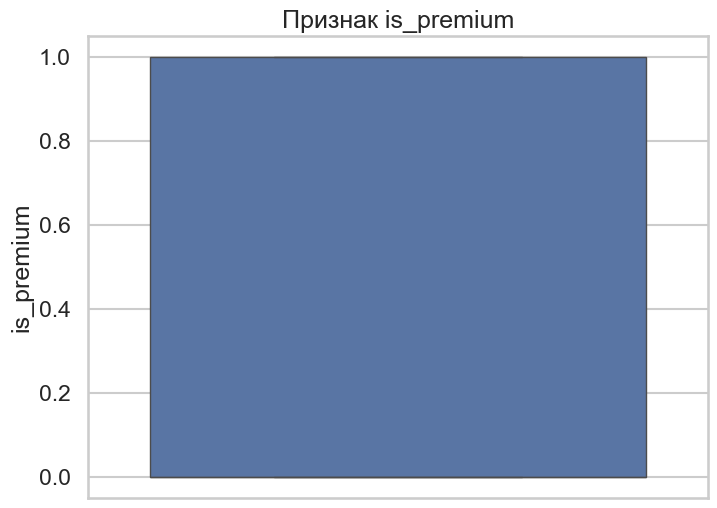

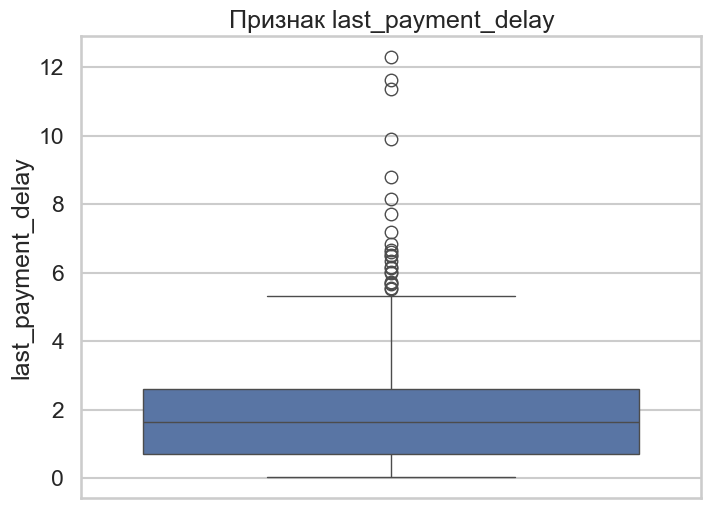

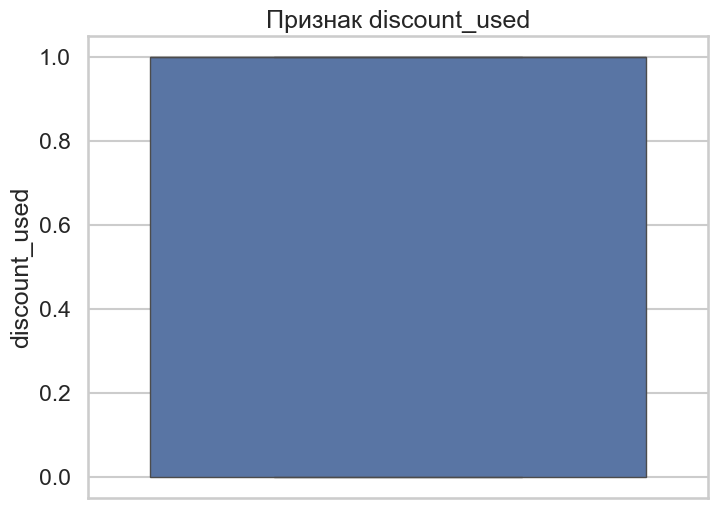

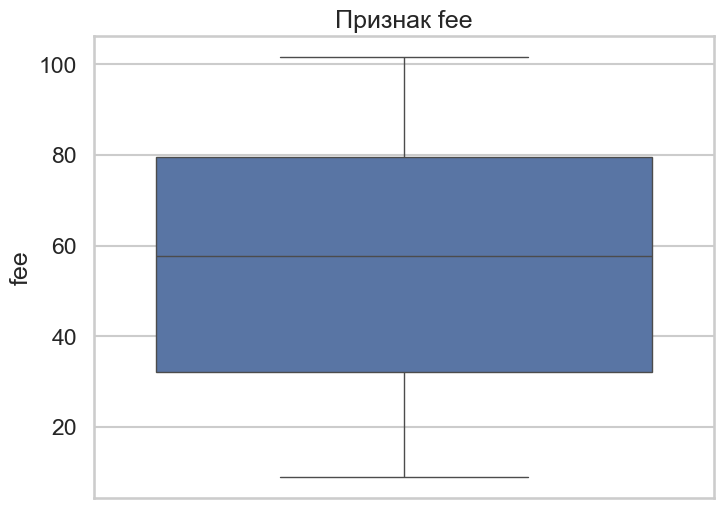

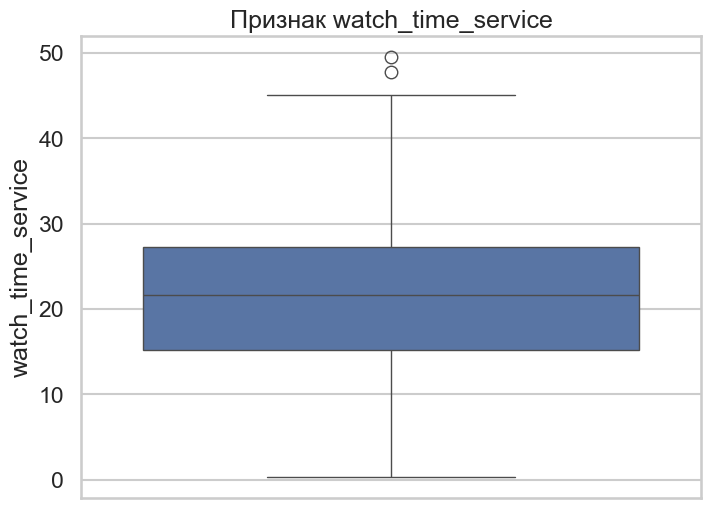

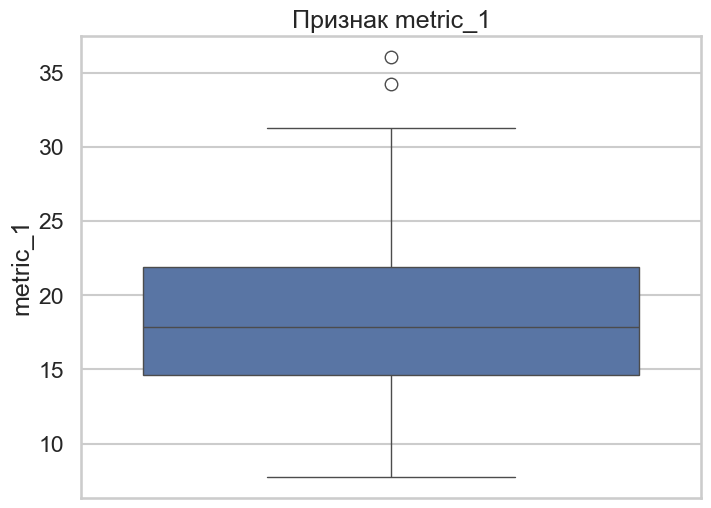

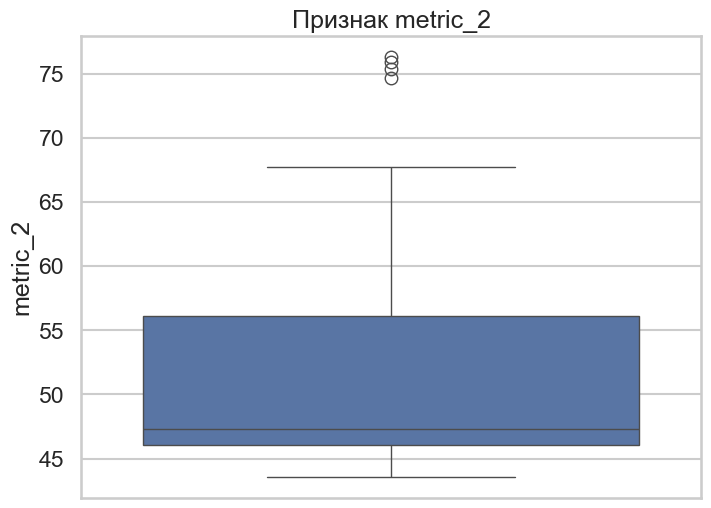

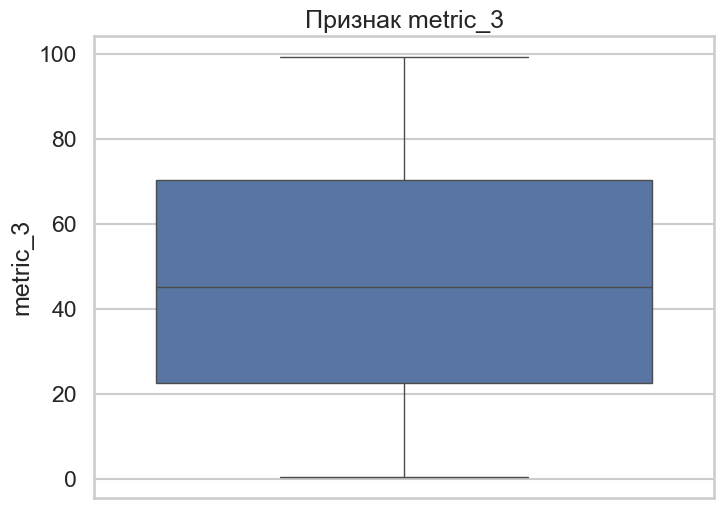

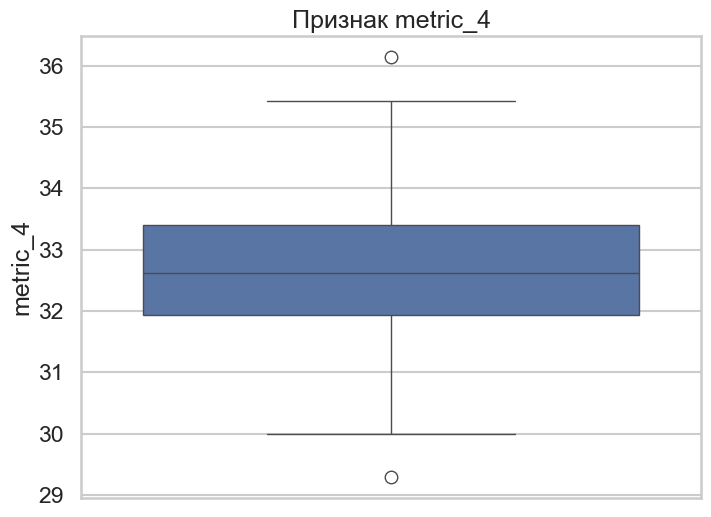

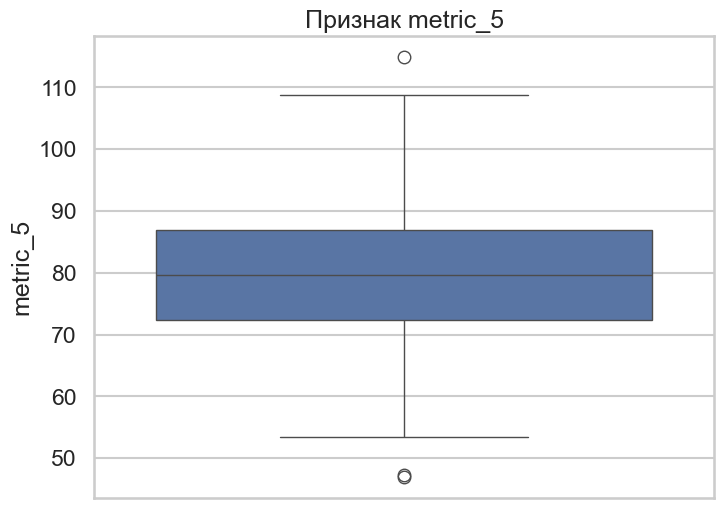

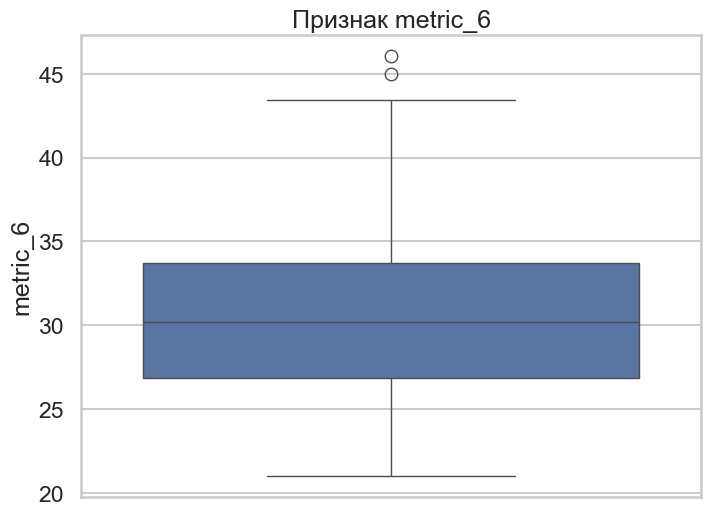

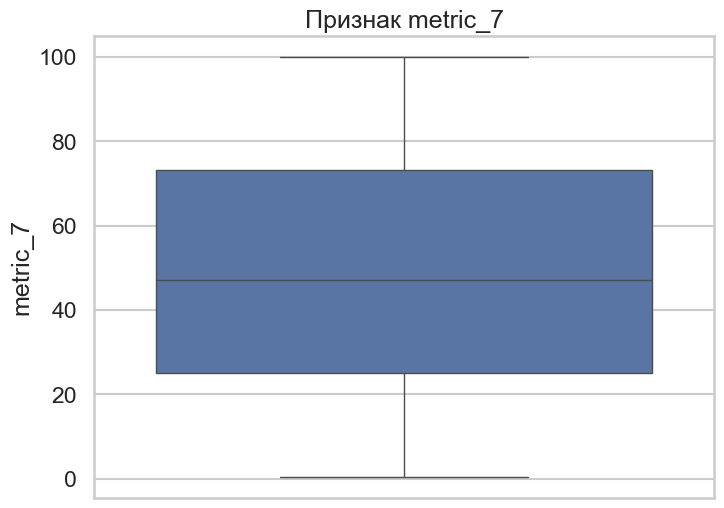

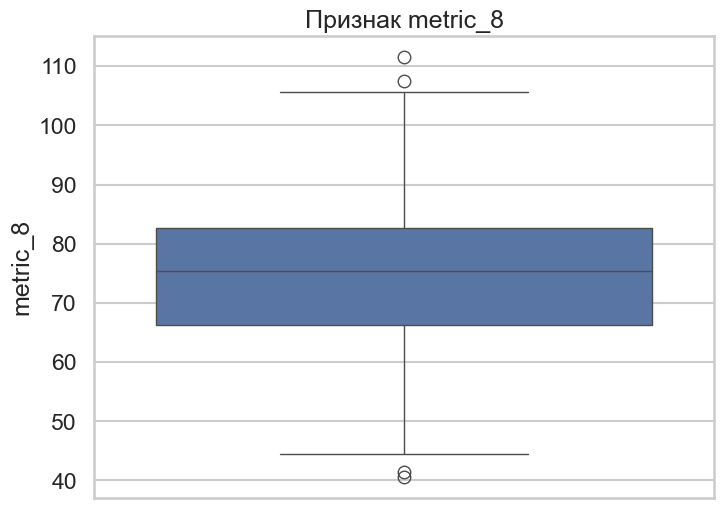

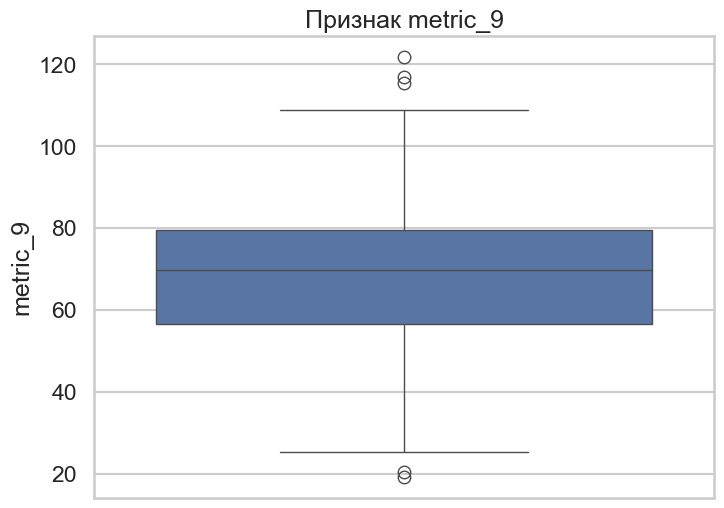

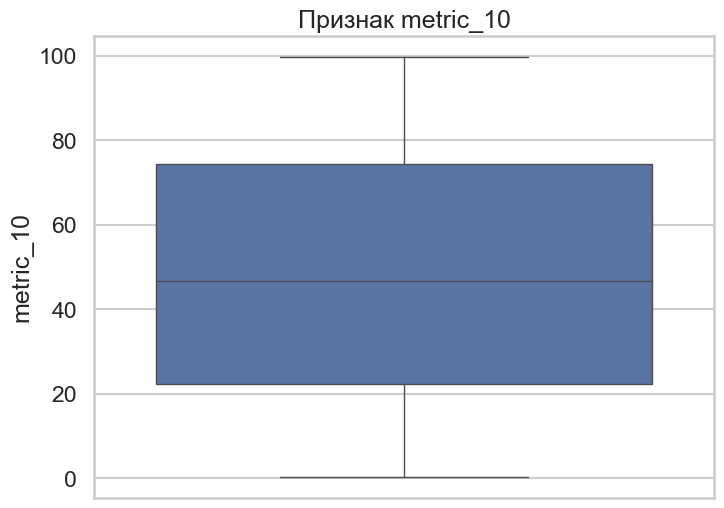

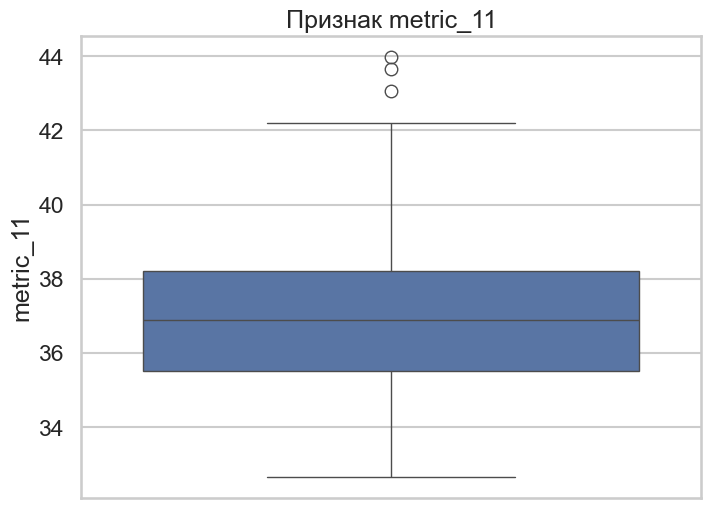

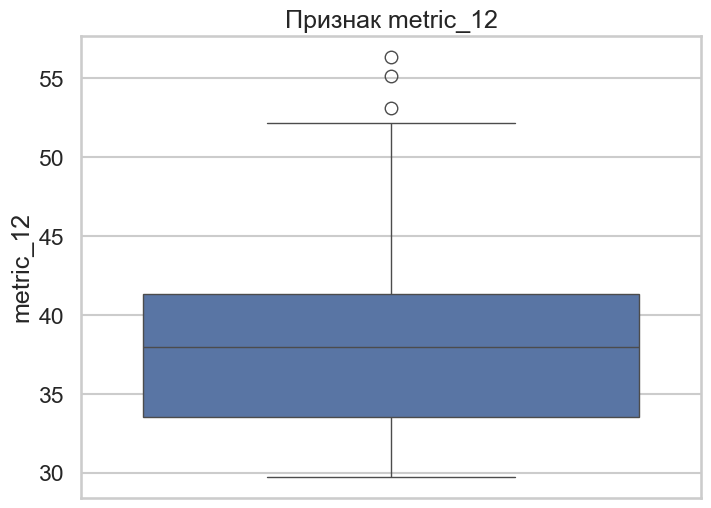

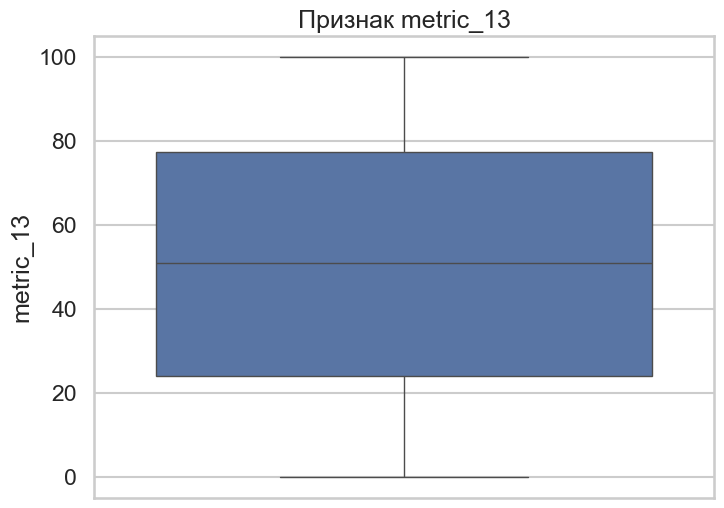

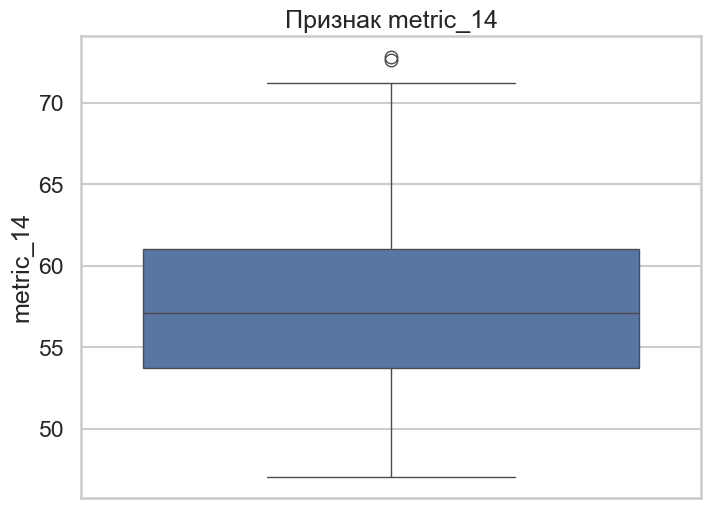

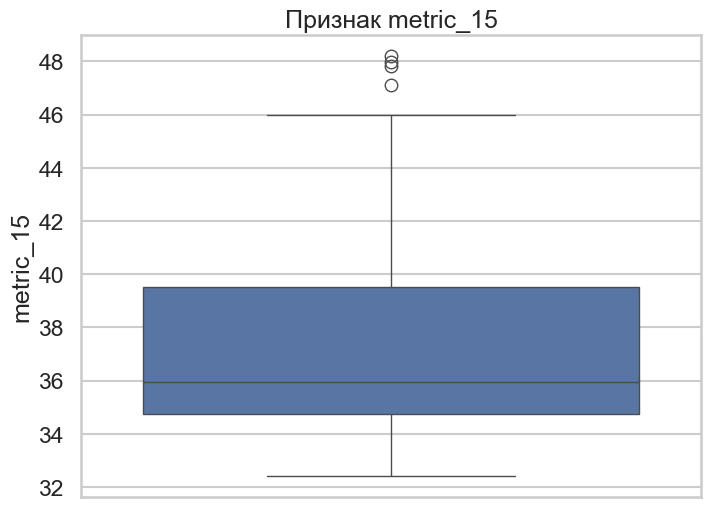

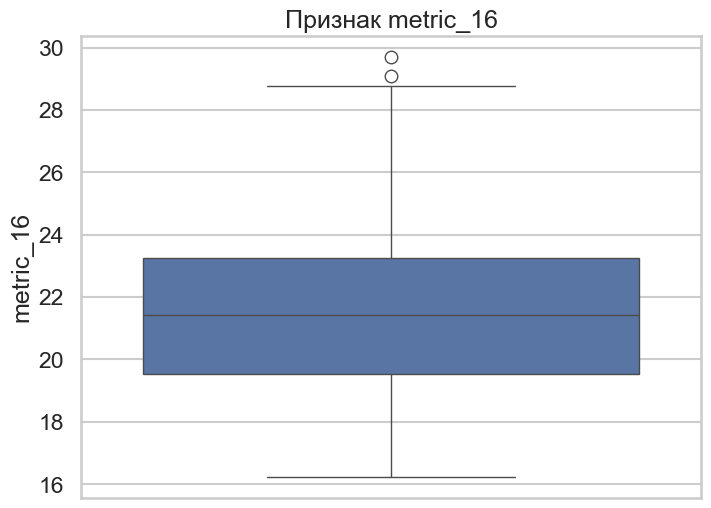

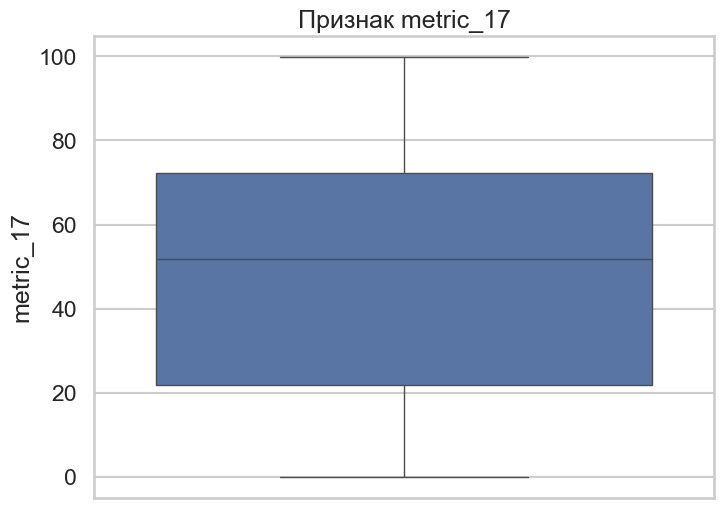

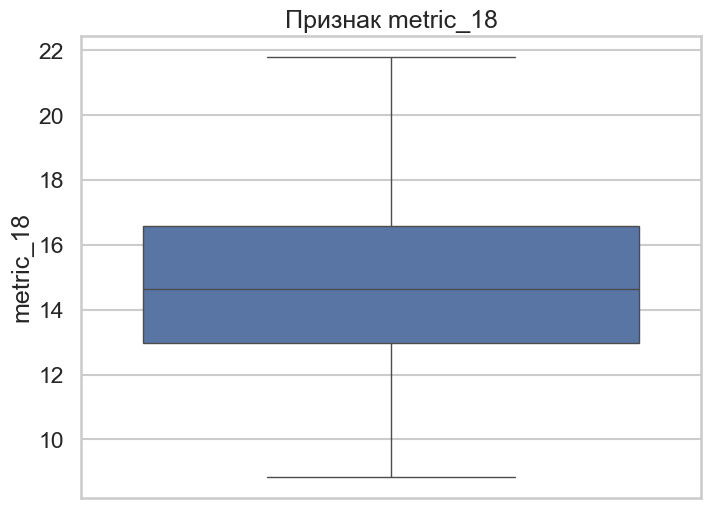

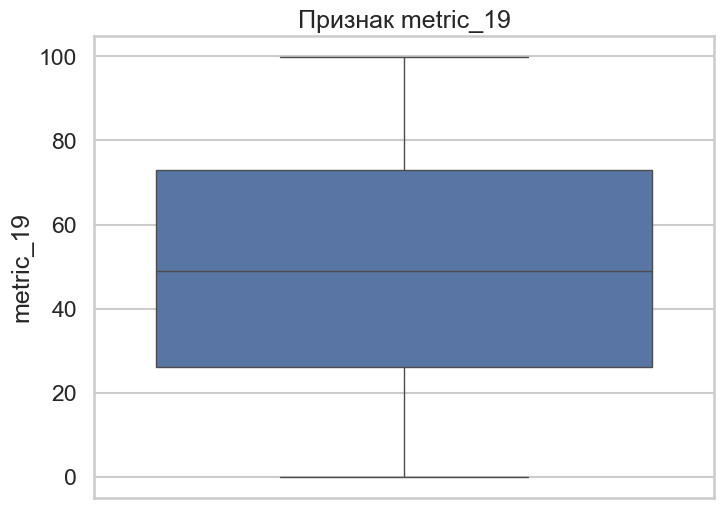

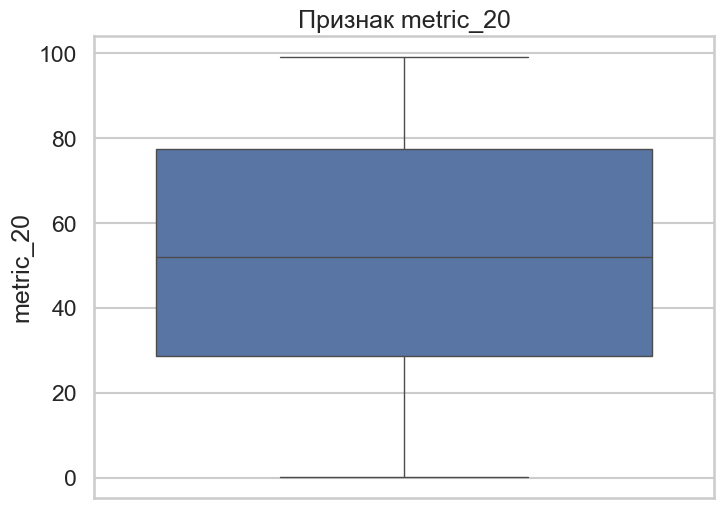

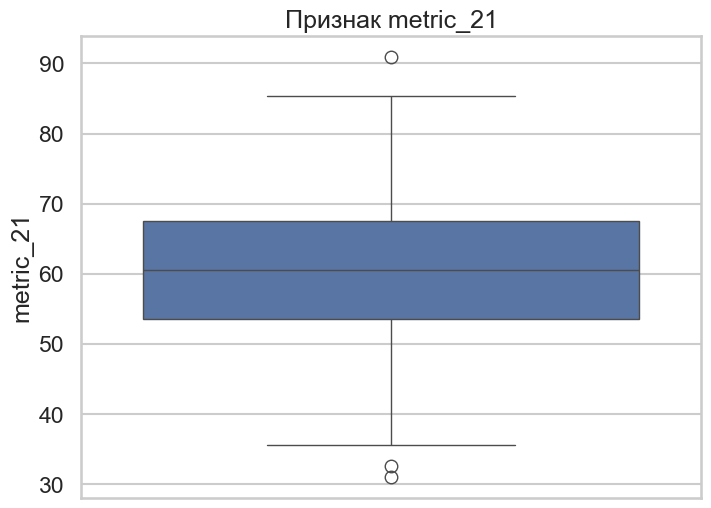

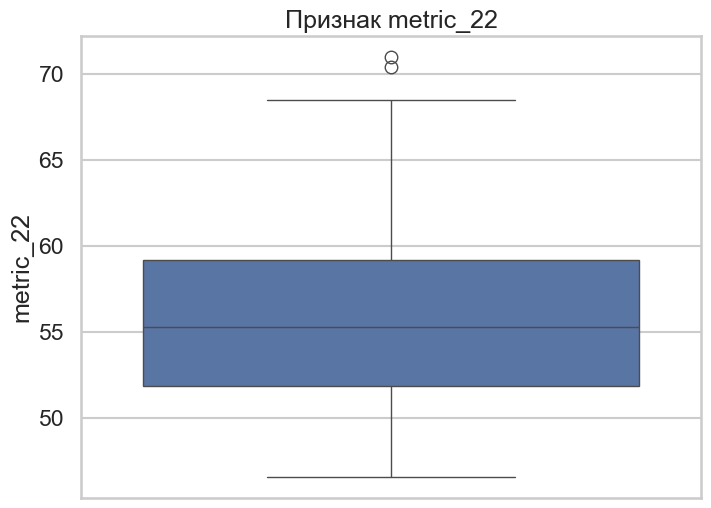

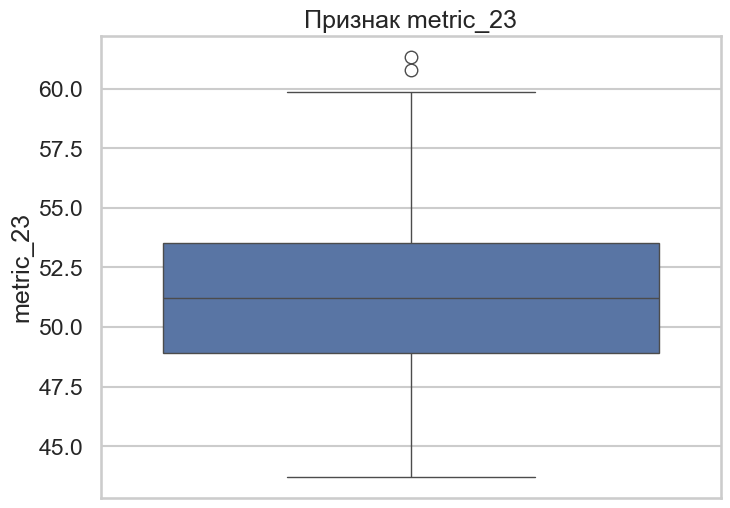

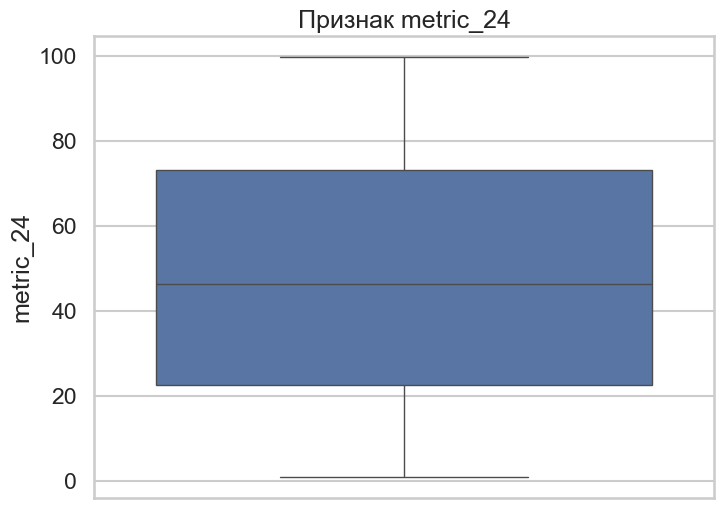

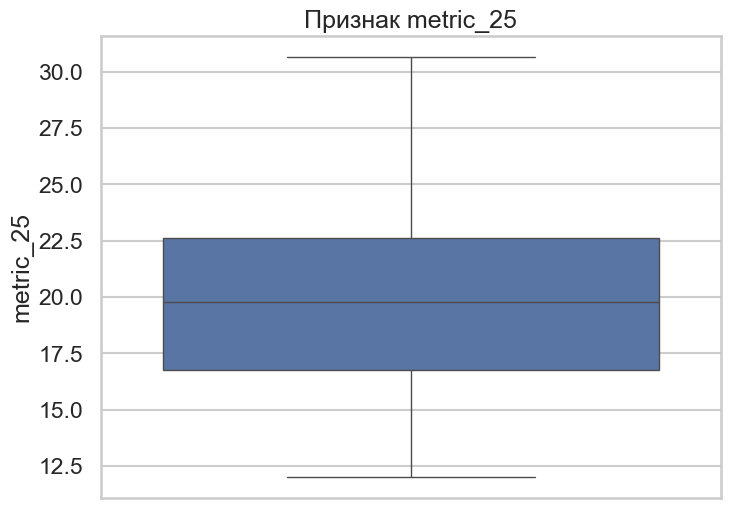

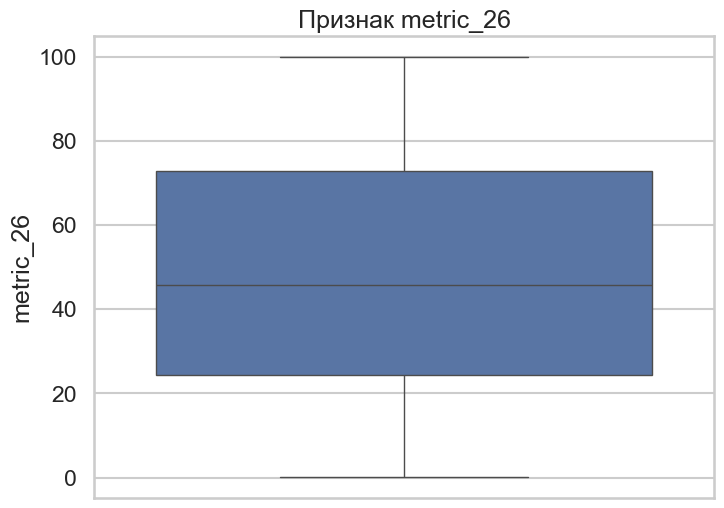

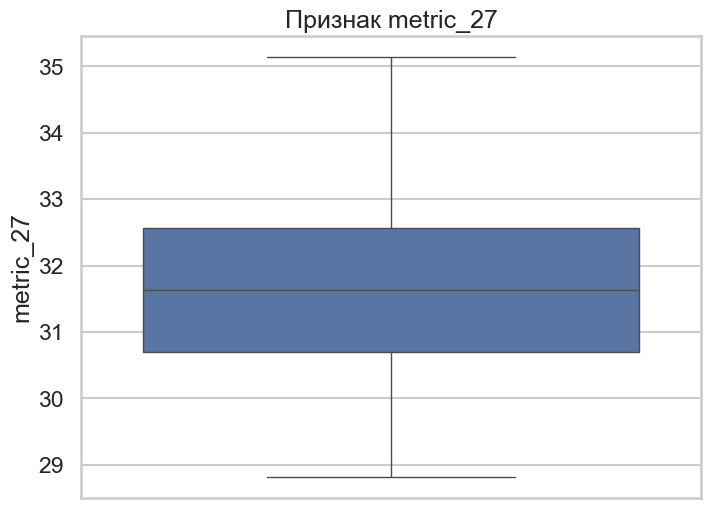

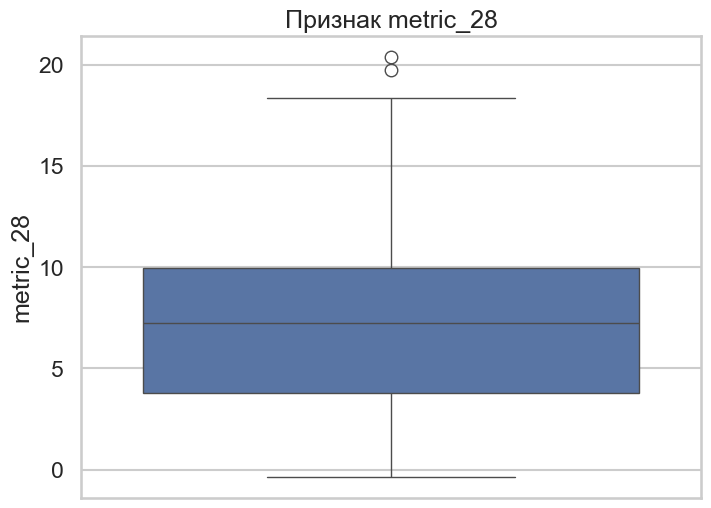

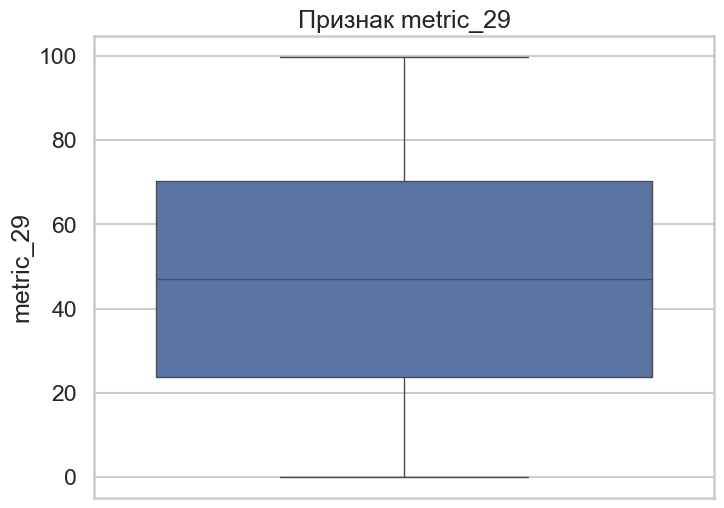

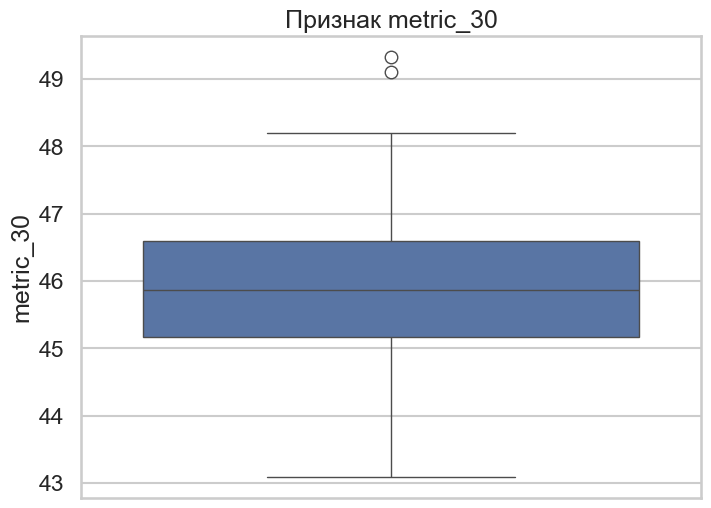

In [82]:
for column in X_train.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(X_train[column])
    plt.title(f'Признак {column}')
    plt.show()

Видим потенциальные выбросы. Попробуем обучить модель с ними

In [83]:
C_grid = np.logspace(np.log10(0.025), np.log10(0.15), 20)
C_grid = np.logspace(-2, -1, 20)
metrics = []

for C in C_grid:
    model = LogisticRegression(C=C)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    metrics.append(accuracy_score(y_test, y_pred))

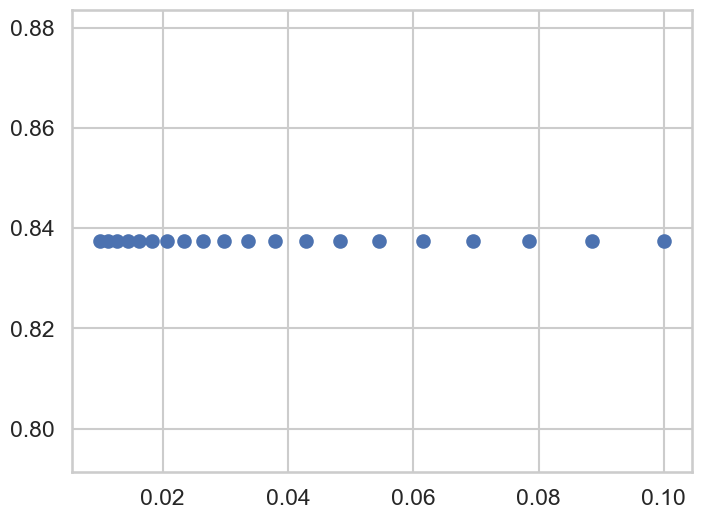

In [84]:
plt.figure(figsize=(8, 6))
plt.scatter(C_grid, metrics)
plt.show()

In [85]:
from sklearn.model_selection import GridSearchCV

In [86]:
param_grid = {'C': np.logspace(-2, -1, 20),
              'l1_ratio': np.linspace(0, 1, 10)}

grid_model = GridSearchCV(estimator=LogisticRegression(penalty='elasticnet', solver='saga', max_iter=500),
                          param_grid=param_grid,
                          n_jobs=-1)

grid_model.fit(X_train_scaled, y_train)

GridSearchCV(estimator=LogisticRegression(max_iter=500, penalty='elasticnet',
                                          solver='saga'),
             n_jobs=-1,
             param_grid={'C': array([0.01      , 0.01128838, 0.01274275, 0.0143845 , 0.01623777,
       0.01832981, 0.02069138, 0.02335721, 0.02636651, 0.02976351,
       0.03359818, 0.0379269 , 0.04281332, 0.0483293 , 0.05455595,
       0.06158482, 0.06951928, 0.078476  , 0.08858668, 0.1       ]),
                         'l1_ratio': array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ])})

In [87]:
print(grid_model.best_params_)
print(f'Предсказания на треине: {grid_model.best_score_}')
y_pred = grid_model.predict(X_test_scaled)
print(f'Предсказания на тесте: {accuracy_score(y_test, y_pred)}')

{'C': 0.06158482110660264, 'l1_ratio': 0.0}
Предсказания на треине: 0.865625
Предсказания на тесте: 0.8375


In [88]:
model = LogisticRegression(C=0.01)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
accuracy_score(y_test, y_pred)

0.8375

Посмотрим насколько принципиальны точки с самыми большими выбросами

In [89]:
mask = X_train['last_payment_delay'] > 6
print(f'Вероятность отказаться от подписки с сильно просроченным платежом: {sum(y_train[mask])/len(y_train[mask])}')
print(f'Вероятность отказаться от подписки вообще: {sum(y_train)/len(y_train)}')

Вероятность отказаться от подписки с сильно просроченным платежом: 0.23529411764705882
Вероятность отказаться от подписки вообще: 0.14375


При разных RANDOM_STATE получил, что иногда отношениея как сейчас, а иногда равны, поэтому чистить выбросы не будем. Нужно запускать модель много раз и смотреть. В текущем варианте можно поставить больше вес этого признака

In [90]:
# X_train.loc[mask, 'last_payment_delay'] = X_train.loc[~mask, 'last_payment_delay'].mean()
# X_train_scaled = scaler.fit_transform(X_train)
# model = LogisticRegression(C=0.01)
# model.fit(X_train_scaled, y_train)
# y_pred = model.predict(X_test_scaled)
# accuracy_score(y_test, y_pred)

Почистим польностью метрики

In [91]:
cols = [f"metric_{i}" for i in range(1, 31)]

q1 = X_train[cols].quantile(0.25)
q3 = X_train[cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

for c in cols:
    mask = (X_train[c] < lower[c]) | (X_train[c] > upper[c])
    non_out_mean = X_train.loc[~mask, c].mean()
    if pd.isna(non_out_mean):
        non_out_mean = X_train[c].median()
    X_train.loc[mask, c] = non_out_mean


In [92]:
X_train_scaled = scaler.fit_transform(X_train)
model = LogisticRegression(C=0.01)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
accuracy_score(y_test, y_pred)

0.8375

Для точности можно так же как и выше понять, в каких из них выбросы несут важую информацию. Пока удалим все вне усов

In [93]:
X_test = df_test
X_test_scaled = scaler.transform(X_test)
y_pred = model.predict(X_test_scaled)

In [94]:
y_pred


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

In [95]:
import numpy as np
import pandas as pd

# ваши переменные: X_test (= df_test), X_test_scaled, y_pred
# X_test = df_test
# X_test_scaled = scaler.transform(X_test)
# y_pred = model.predict(X_test_scaled)

# 1) Получаем id'ы (несколько вариантов)
def get_ids(X_test):
    # если есть столбец 'id' — используем его
    if isinstance(X_test, pd.DataFrame) and 'id' in X_test.columns:
        return X_test['id'].to_numpy()
    # если индекс не стандартный RangeIndex, используем индекс
    if isinstance(X_test, pd.DataFrame) and not isinstance(X_test.index, pd.RangeIndex):
        return X_test.index.to_numpy()
    # иначе — создаём последовательные id от 0 до n-1
    return np.arange(len(y_pred))

ids = get_ids(X_test)

# 2) Приводим y_pred к одномерному массиву меток 0/1
y = np.asarray(y_pred)

if y.ndim > 1:
    # Вероятности в виде (n,1) или (n,2) или one-hot (n, k)
    if y.shape[1] == 1:
        # вероятности для положительного класса
        labels = (y.ravel() >= 0.5).astype(int)
    elif y.shape[1] == 2:
        # вероятности для двух классов -> берем argmax
        labels = np.argmax(y, axis=1).astype(int)
    else:
        # multiclass / one-hot -> argmax
        labels = np.argmax(y, axis=1).astype(int)
else:
    # одномерный массив — может быть float (вероятности) или уже метки
    if np.issubdtype(y.dtype, np.floating):
        labels = (y >= 0.5).astype(int)
    else:
        labels = y.astype(int)

# 3) Проверка длины
if len(ids) != len(labels):
    raise ValueError(f"Length mismatch: ids ({len(ids)}) vs predictions ({len(labels)})")

# 4) Собираем DataFrame и сохраняем
submission = pd.DataFrame({'id': ids, 'churn': labels})
# Убедимся, что churn — int
submission['churn'] = submission['churn'].astype(int)

# посмотреть первые строки
print(submission.head())

# сохранить в CSV без индекса
submission.to_csv('submission.csv', index=False)
print("Saved to submission.csv")


    id  churn
0  190      0
1  434      0
2  497      0
3  455      0
4  302      0
Saved to submission.csv
